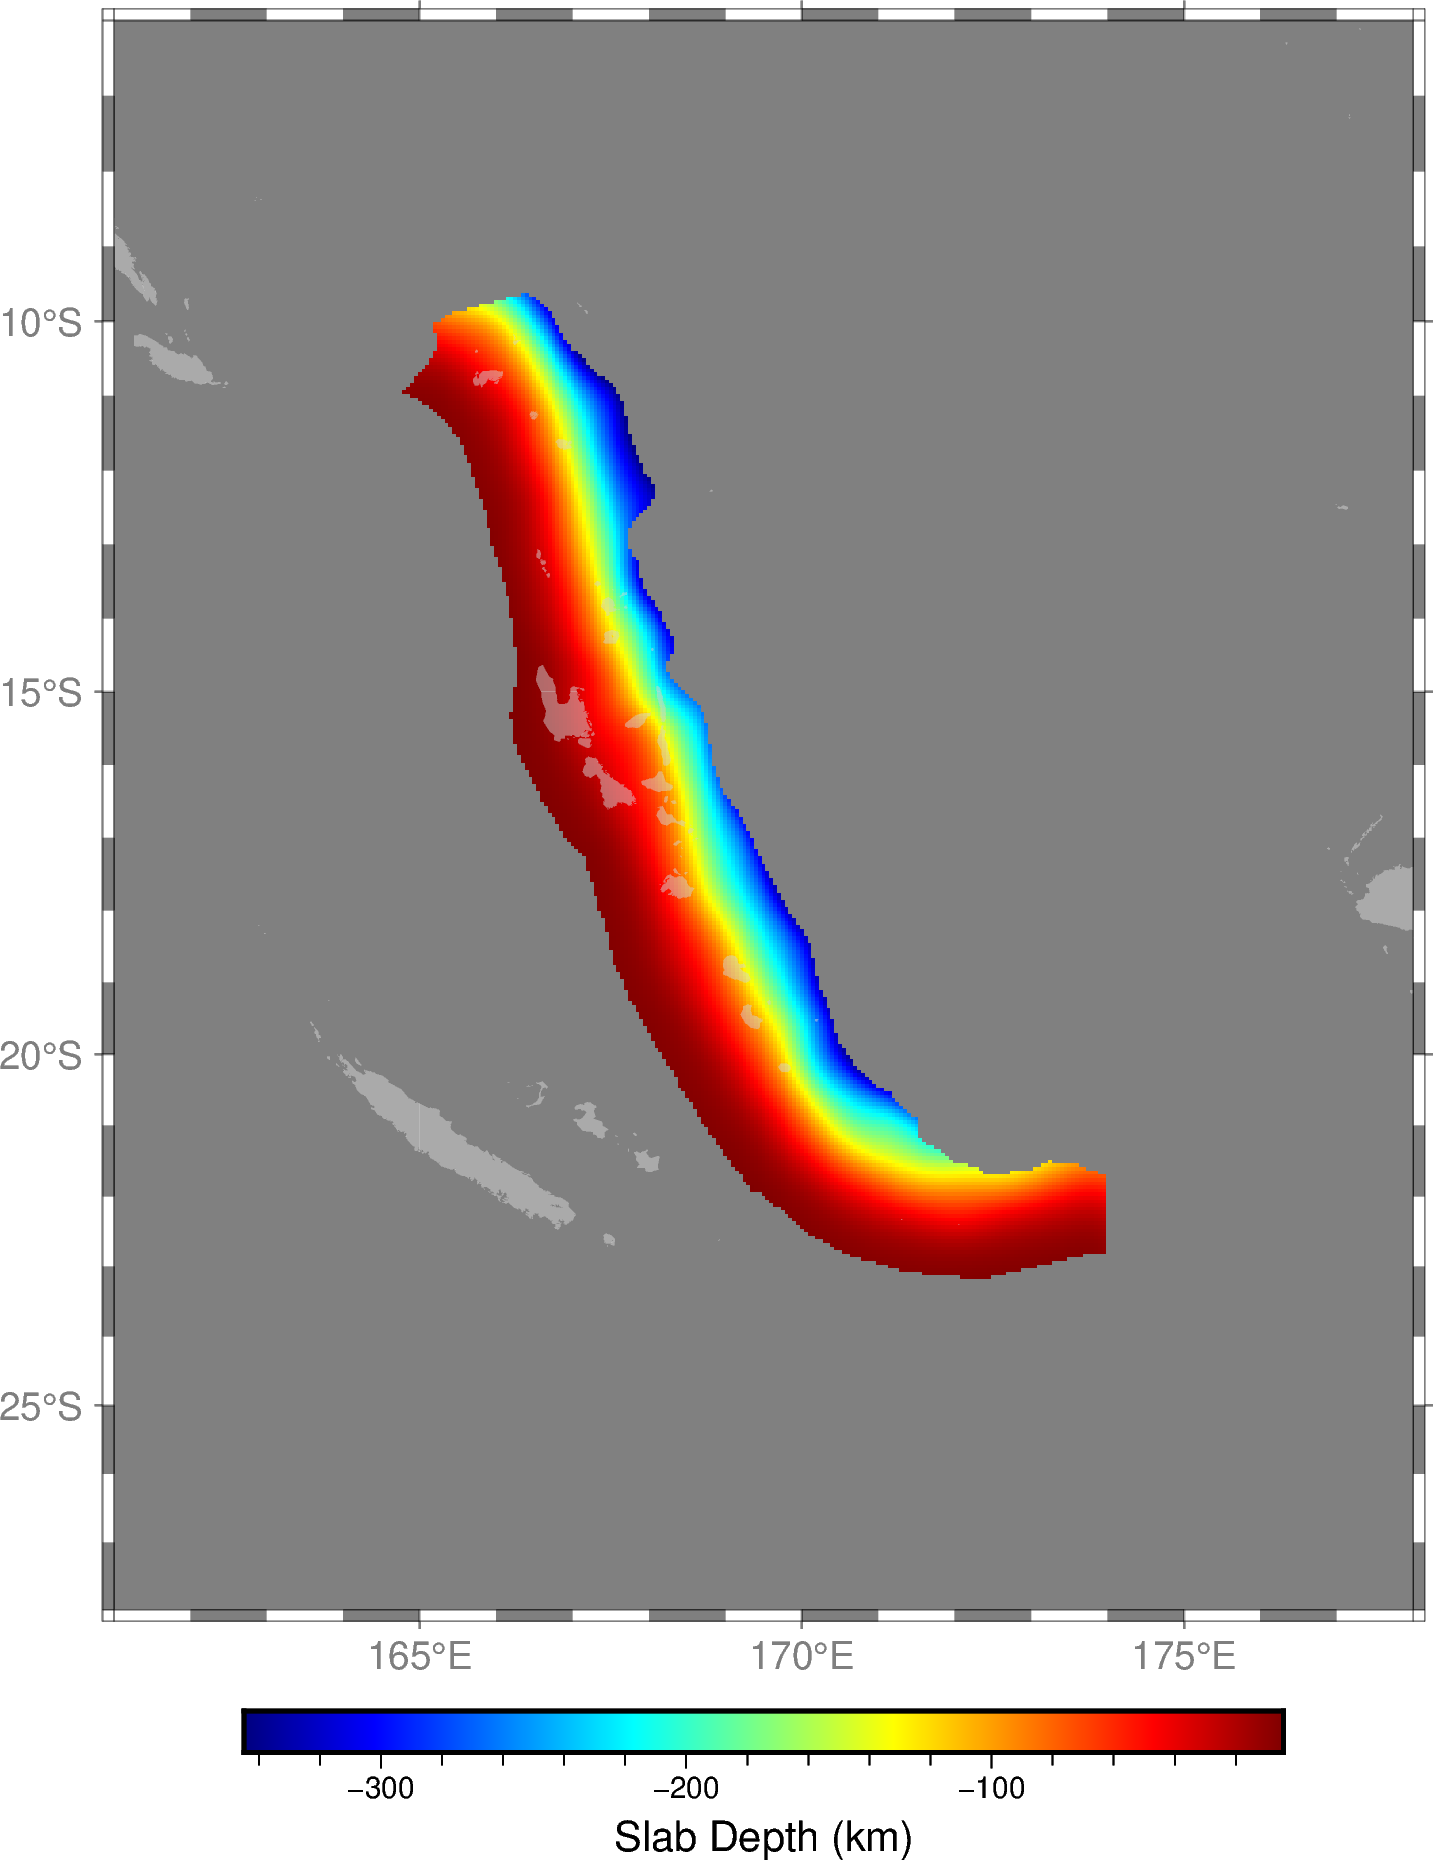

In [ ]:
import gplately
import pandas as pd
import pygmt
import xarray as xr
import geopandas as gpd
import numpy as np

data_path = "Slab2 Depth path to your data file here.nc"  # Replace with the actual path to your data file
slab_depth = xr.open_dataset(data_path)

fig = pygmt.Figure()

fig.grdimage(grid=slab_depth.z, cmap="jet",projection="Y11c")
fig.coast(projection="Y11c", land="lightgrey", frame="af",transparency=50)

fig.colorbar(frame='af+lSlab Depth (km)')


fig.show()

In [104]:
lon_max=int(slab_depth.x.max())
lon_min=int(slab_depth.x.min())
lat_min=int(slab_depth.y.min())
lat_max=int(slab_depth.y.max())

lon_range=abs(lon_max-lon_min)
lat_range=abs(lat_max-lat_min)


print(lon_min,lon_max,lat_min,lat_max)


161 178 -28 -6


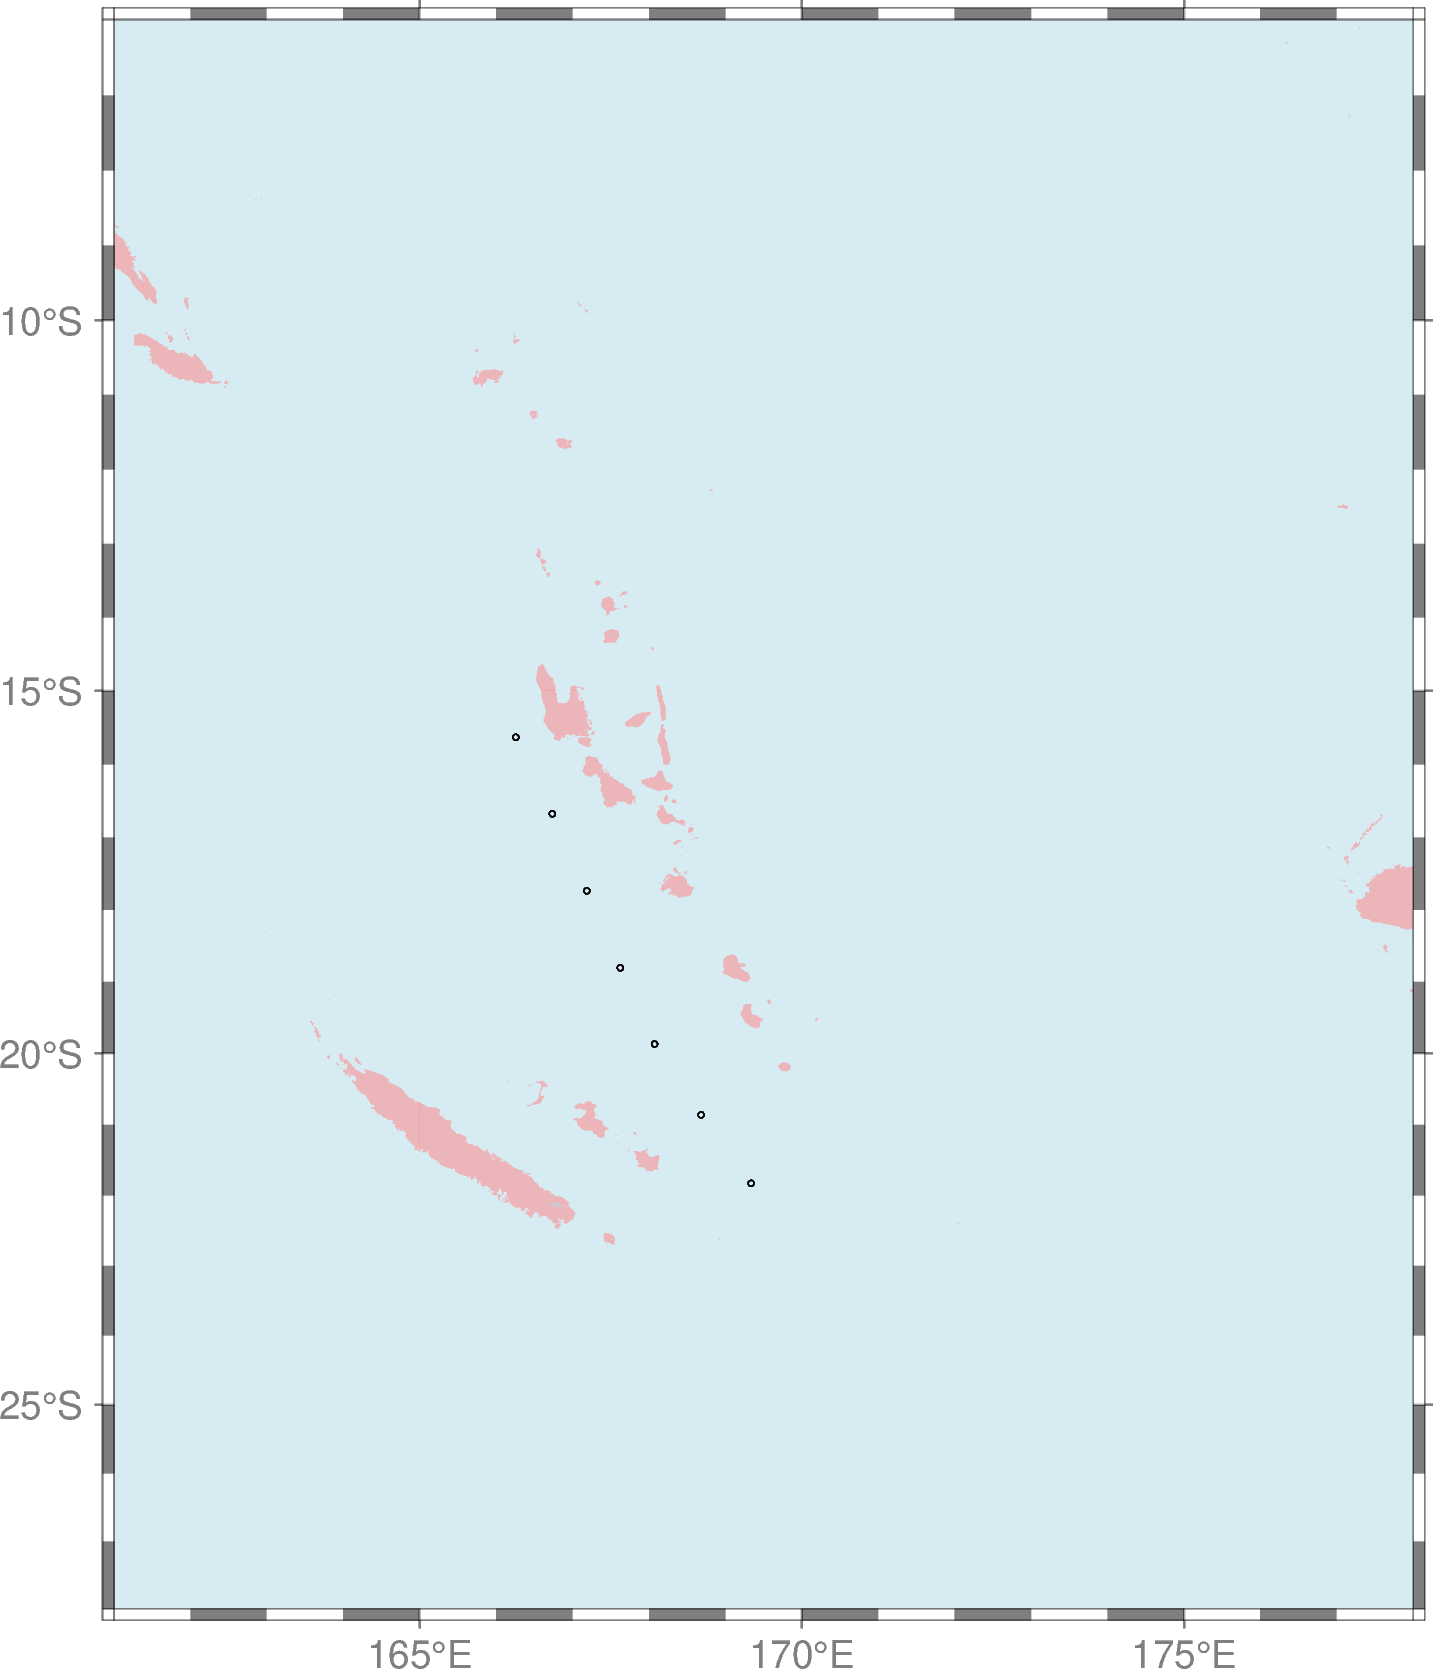

In [ ]:
import geopandas as gpd
import DefineProfile

Subduction_zones_Path = "Subduction_zones_North_Fiji.geojson"  # Replace with the actual path to your GeoJSON file
gdf = gpd.read_file(Subduction_zones_Path)
region  = [lon_min,lon_max,lat_min,lat_max]
fig = pygmt.Figure()
fig.coast(region=region, projection="Y11c", land="lightred", water="lightblue", frame="af",transparency=50)
fig.plot(x=gdf["Lon"], y=gdf["Lat"], style="c0.05c", label="Subduction zones")
fig.show()

#### Profiles ####


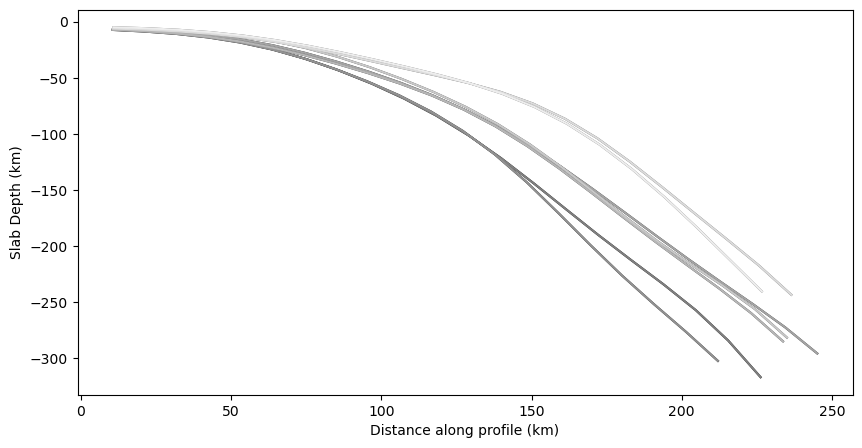

In [ ]:
import matplotlib.pyplot as plt
profiles=DefineProfile.define_profiles(Subduction_zones_Path, 50)

plt.figure(figsize=(10,5))

n = len(profiles)
for i, profile in enumerate(profiles):
    depth_interped = slab_depth.interp(
        x=("points", profile['Longitude']),
        y=("points", profile['Latitude']),
        method="linear"
    )

    profile['Slab Depth'] = depth_interped.z.values
    depth = profile['Slab Depth']
    x = profile['Distance']

    # make color gradually darker (1=white → 0=black)
    gray = i / n  
    plt.plot(x, depth, color=str(gray))
    plt.xlabel('Distance along profile (km)')
    plt.ylabel('Slab Depth (km)')

plt.show()

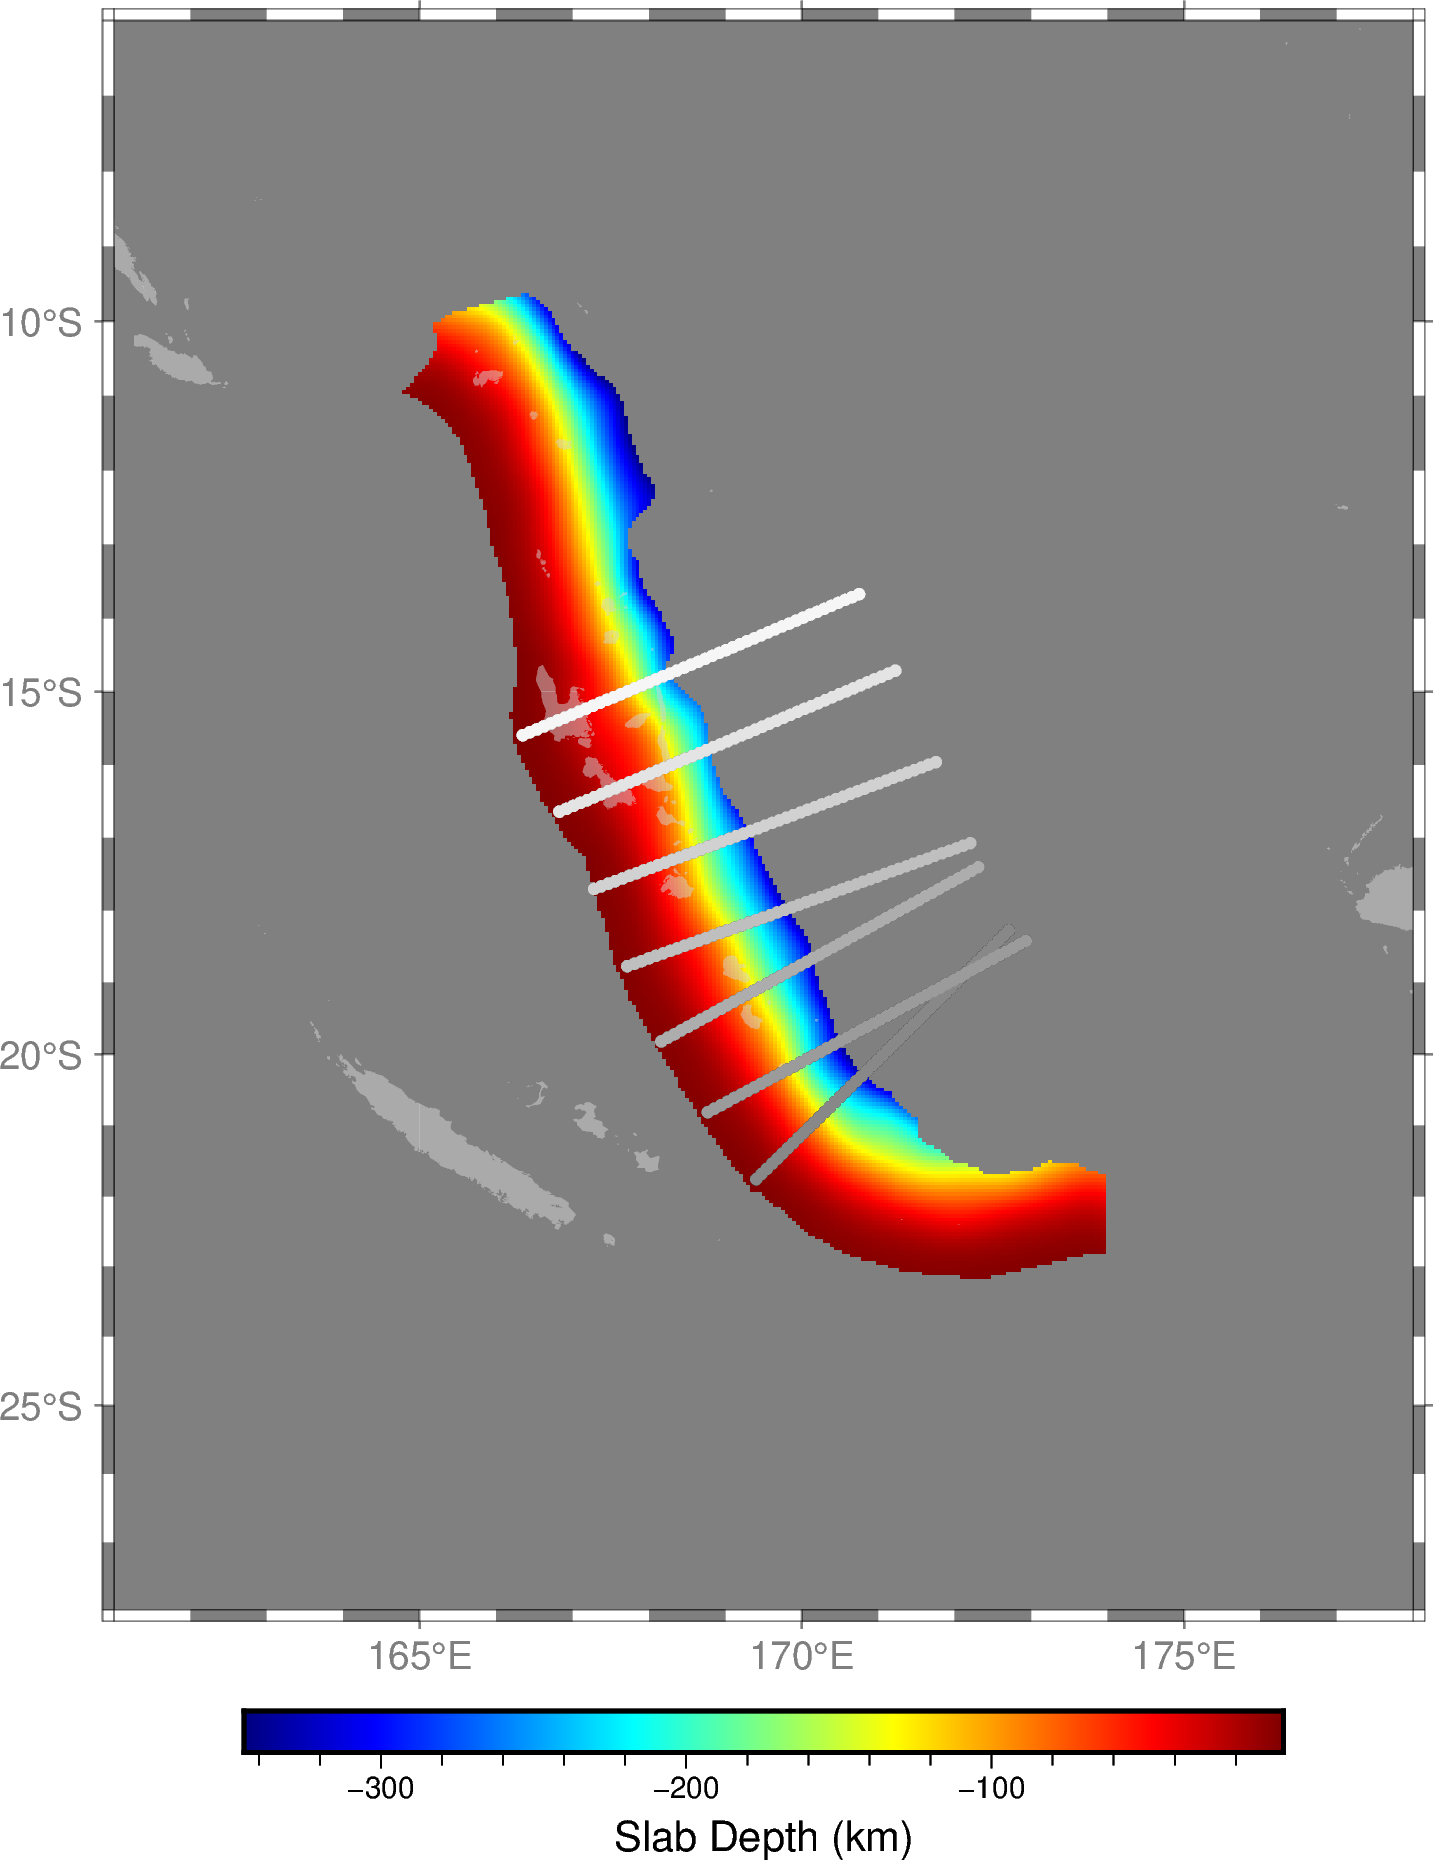

In [ ]:
fig = pygmt.Figure()
region=[lon_min, lon_max, lat_min, lat_max]

fig.grdimage(grid=slab_depth.z,region=region, cmap="jet",projection="Y11c")
fig.coast(region=region, land="lightgrey", frame="af",transparency=50)
fig.colorbar(frame='af+lSlab Depth (km)')


pygmt.makecpt(cmap="gray", series=[0,len(profiles),1])
for i, profile in enumerate(profiles):
    fig.plot(x=profile['Longitude'], y=profile['Latitude'], style="c0.1c", fill="+z", cmap=True, zvalue=i)


fig.show()

### Slab Dip Extraction ###


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Depths_clipped=[]
for profile in profiles:
    depth_clipped = profile[(profile['Slab Depth'] >= -300) & (profile['Slab Depth'] <= -200)]
    depth_clipped = depth_clipped.reset_index(drop=True)
    Depths_clipped.append(depth_clipped)

Dip_degree = []
Dip_deviation = []
for profile in Depths_clipped:   
    if len(profile['Slab Depth']) < 2:
        continue 
    dz = np.gradient(profile['Slab Depth'])
    dx = np.gradient(profile['Distance'])

    dip_rad = np.arctan2(dz, dx)
    profile['dip_deg'] = np.degrees(np.abs(dip_rad))
    Dip_degree.append(np.average(profile['dip_deg']))

Ave_dip_degree = np.mean(Dip_degree)
sd=np.std(Dip_degree)

print(Dip_degree)
print(Ave_dip_degree,sd)

[np.float64(63.04312548854097), np.float64(66.75620953954171), np.float64(61.224763139510266), np.float64(61.9436171468574), np.float64(62.5344776498094), np.float64(63.601024189250325), np.float64(63.74477661824555), np.float64(63.04312548854097), np.float64(66.75620953954171), np.float64(61.224763139510266), np.float64(61.9436171468574), np.float64(62.5344776498094), np.float64(63.601024189250325), np.float64(63.74477661824555)]
63.2639991102508 1.6485121079387652
